# 📊 Bollinger Bands (BB) Technical Indicator Project

## 🔹 Overview
This project demonstrates how to calculate and visualize **Bollinger Bands (BB)**,  
a volatility-based technical indicator developed by John Bollinger.

Bollinger Bands consist of:
- A **moving average (MA)** in the middle (usually 20 periods).
- An **upper band** = MA + k × standard deviation.
- A **lower band** = MA – k × standard deviation.

The bands expand during high volatility and contract during low volatility.  
Traders often use Bollinger Bands for **mean reversion** or to identify **volatility breakouts**.

---

## 🔹 Technical Background

### Formula
1. Middle Band (Moving Average):
\[
MB_t = \frac{1}{n}\sum_{i=0}^{n-1} P_{t-i}
\]

2. Standard Deviation:
\[
\sigma_t = \sqrt{\frac{1}{n}\sum_{i=0}^{n-1}(P_{t-i} - MB_t)^2}
\]

3. Upper & Lower Bands:
\[
UB_t = MB_t + k\sigma_t, \quad LB_t = MB_t - k\sigma_t
\]

Typical parameters: **n = 20**, **k = 2**.



In [1]:
print("Hello world!")

Hello world!


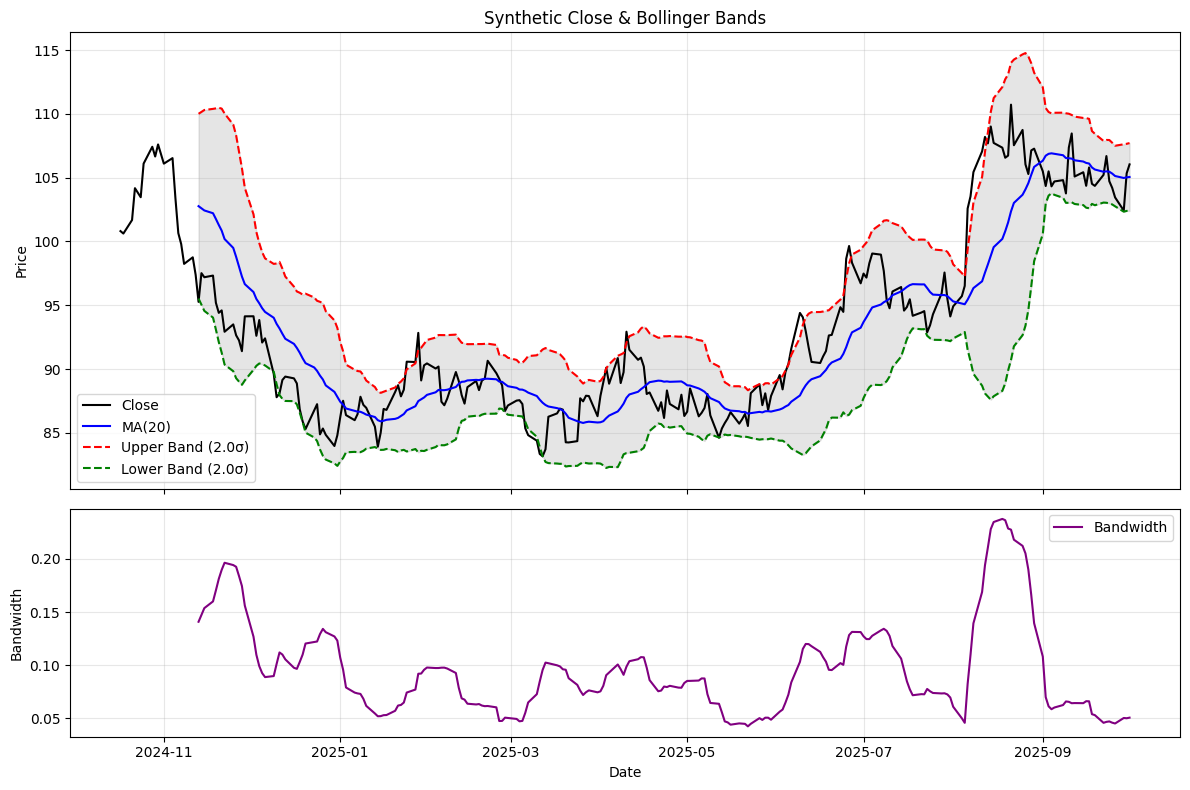

Mode: Synthetic
Rows: 250
Last Close: 106.04
MA(20): 105.05
Upper Band: 107.71 | Lower Band: 102.39
Bandwidth: 0.0506


In [2]:
# ==== Bollinger Bands Project ====
# Works with synthetic data by default. Set RUN_MODE="yfinance" for real prices.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- Config --------
RUN_MODE   = "synthetic"   # "synthetic" or "yfinance"
TICKER     = "AAPL"        # only used if RUN_MODE="yfinance"
PERIOD     = "1y"          # yfinance only
INTERVAL   = "1d"          # yfinance only

BB_LEN = 20   # moving average length
BB_K   = 2.0  # number of standard deviations
# -------------------------

# 1) Load Data
if RUN_MODE == "yfinance":
    try:
        import yfinance as yf
        df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, auto_adjust=True, progress=False)
        if df is None or df.empty:
            raise RuntimeError("No data returned.")
        close = pd.to_numeric(df["Close"], errors="coerce").dropna()
        title = f"{TICKER} Close & Bollinger Bands"
    except Exception as e:
        print("Falling back to synthetic data because:", e)
        RUN_MODE = "synthetic"

if RUN_MODE == "synthetic":
    np.random.seed(42)
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=250)
    mu, sigma, dt = 0.10, 0.25, 1/252
    z = np.random.normal(size=len(dates))
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    price = 100*np.exp(np.cumsum(log_ret))
    close = pd.Series(price, index=dates, name="Close")
    title = "Synthetic Close & Bollinger Bands"

# 2) Compute Bollinger Bands
mid = close.rolling(BB_LEN).mean()
std = close.rolling(BB_LEN).std(ddof=0)
upper = mid + BB_K * std
lower = mid - BB_K * std
bandwidth = (upper - lower) / mid

# 3) Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True,
                               gridspec_kw={'height_ratios':[2,1]})

# Top panel: Price + Bands
ax1.plot(close.index, close, label="Close", color="black")
ax1.plot(mid.index, mid, label=f"MA({BB_LEN})", color="blue")
ax1.plot(upper.index, upper, label=f"Upper Band ({BB_K}σ)", color="red", linestyle="--")
ax1.plot(lower.index, lower, label=f"Lower Band ({BB_K}σ)", color="green", linestyle="--")
ax1.fill_between(close.index, lower, upper, color="gray", alpha=0.2)
ax1.set_title(title)
ax1.set_ylabel("Price")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Bottom panel: Bandwidth (volatility measure)
ax2.plot(bandwidth.index, bandwidth, label="Bandwidth", color="purple")
ax2.set_ylabel("Bandwidth")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# 4) Summary
print("Mode:", "Real (yfinance)" if RUN_MODE=="yfinance" else "Synthetic")
print("Rows:", len(close))
print("Last Close:", round(close.iloc[-1],2))
print(f"MA({BB_LEN}):", round(mid.iloc[-1],2))
print(f"Upper Band: {round(upper.iloc[-1],2)} | Lower Band: {round(lower.iloc[-1],2)}")
print(f"Bandwidth: {round(bandwidth.iloc[-1],4)}")
